In [1]:
# import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
from matplotlib import colormaps as cmap
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
# import bisect
# import uuid
from enum import Enum
# import requests
from pathlib import Path
import os

from fame import *
# import copy
import random
R_earth_km = 6371

## Create the satellites

In [2]:
tle_file_name_json = "all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [3]:
# planet_satellites = []
# 14-19 decayed
# tle_file_name_txt = "all_tles_20260121.txt"

skysat_fov_rad ={"RGB": 5.*np.pi/180.}

skysat_satellites = [
    Satellite("SKYSAT-A",   Orbital("SKYSAT 1",   tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-B",   Orbital("SKYSAT 2",   tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C1",  Orbital("SKYSAT C1",  tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2",  Orbital("SKYSAT C2",  tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C3",  Orbital("SKYSAT C3",  tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C4",  Orbital("SKYSAT C4",  tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C5",  Orbital("SKYSAT C5",  tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C6",  Orbital("SKYSAT C6",  tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C7",  Orbital("SKYSAT C7",  tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C8",  Orbital("SKYSAT C8",  tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C9",  Orbital("SKYSAT C9",  tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=skysat_fov_rad),
]

pelican_fov_rad ={"RGB": 3.*np.pi/180.}
pelican_satellites = [
    Satellite("PELICAN-3001", Orbital("PELICAN 3001", tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=pelican_fov_rad),
    Satellite("PELICAN-3009", Orbital("PELICAN 3009", tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=pelican_fov_rad),
    Satellite("PELICAN-300A", Orbital("PELICAN-3",    tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=pelican_fov_rad),
    Satellite("PELICAN-300B", Orbital("PELICAN-4",    tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=pelican_fov_rad),
    Satellite("PELICAN-5",    Orbital("PELICAN-5",    tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=pelican_fov_rad),
    Satellite("PELICAN-6",    Orbital("PELICAN-6",    tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=pelican_fov_rad),
]
tanager_fov_rad ={"RGB": 2.5*np.pi/180.}
tanager_satellites = [
    Satellite("TANAGER-4001", Orbital("TANAGER 4001", tle_file=tle_file_name_txt), instrument_fov_rad=tanager_fov_rad),

]
# 1-6 and 8 decayed
umbra_fov_rad ={"RGB": 2.5*np.pi/180.}
umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt), instrument_fov_rad=umbra_fov_rad),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt), instrument_fov_rad=umbra_fov_rad),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt), instrument_fov_rad=umbra_fov_rad),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt), instrument_fov_rad=umbra_fov_rad),
]
capella_acadia_fov_rad ={"RGB": 2.5*np.pi/180.}
capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt), instrument_fov_rad=capella_acadia_fov_rad),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt), instrument_fov_rad=capella_acadia_fov_rad),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt), instrument_fov_rad=capella_acadia_fov_rad),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt), instrument_fov_rad=capella_acadia_fov_rad),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt), instrument_fov_rad=capella_acadia_fov_rad),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt), instrument_fov_rad=capella_acadia_fov_rad),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]

loft_fov_rad ={"RGB": 2.5*np.pi/180.}
loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=loft_fov_rad)]
ubotica_fov_rad ={"RGB": 2.5*np.pi/180.}
ubotica_satellites = [Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=ubotica_fov_rad)]
mission_control_fov_rad ={"RGB": 2.5*np.pi/180.}
mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=mission_control_fov_rad),]
ac_fov_rad ={"RGB": 2.5*np.pi/180.}
aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=ac_fov_rad),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=["RGB"], instrument_fov_rad=ac_fov_rad),   
]

In [4]:
all_satellites = skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+loft_satellites+ubotica_satellites+mission_control_satellites+aerospace_corp_satellites

## Create the target location

In [5]:
Rotterdam = Location(3.8, 52, 0, "Rotterdam-ish")

observables = [Rotterdam,]

## Add some ground stations for contact planning purposes.

These are used by both the constellation managers, and our broker.

In [6]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

In [7]:
start_time = dt.datetime(2026, 2, 14, 0, 0, 0, 0)
end_time = dt.datetime(2026, 2, 16, 0, 0, 0, 0)

### Add some phenomena to observe.

These represent the location of a target of interest, updated at some frequency.

In [8]:
phenomenon_update_frequency = dt.timedelta(seconds=1800)

phenomena = [
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=start_time,
        end_time=start_time+phenomenon_update_frequency,
        name = Rotterdam.name
    ),
]

avg_speed_kph = 37 # 20 kts
max_iters_per_point = 100

new_heading_rad = 0

while phenomena[-1].end_time<end_time:
    next_point_is_on_land = True
    _it_guesses = 0
    while (next_point_is_on_land and _it_guesses<max_iters_per_point):
        
        _it_guesses+=1
        
        # new_heading_rad = random.random()*2*math.pi # 0 at North
        new_heading_rad += random.normalvariate() # 0 at North

        new_speed_kph = avg_speed_kph + random.normalvariate()
        dy = new_speed_kph*np.cos(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # E-W
        dx = new_speed_kph*np.sin(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # N-S

        dlat_rad = dy/R_earth_km
        dlon_rad = dx/(R_earth_km*np.cos(phenomena[-1].lat_deg*math.pi/180.))

        new_lat_deg = phenomena[-1].lat_deg + dlat_rad*180./math.pi
        new_lon_deg = phenomena[-1].lon_deg + dlon_rad*180./math.pi

        next_point_is_on_land = is_land(new_lon_deg, new_lat_deg)

    previous_end_time = phenomena[-1].end_time
    

    phenomena.append(
        Phenomenon(
            lon_deg = new_lon_deg,
            lat_deg = new_lat_deg,
            alt_km=Rotterdam.alt_km,
            start_time=previous_end_time,
            end_time=previous_end_time+phenomenon_update_frequency,
            name = Rotterdam.name+ " {}-{}".format(previous_end_time.strftime("%Y-%m-%d, %H"),(previous_end_time+phenomenon_update_frequency).strftime("%H"))
        ),
    )

phenomena_with_stationary_toi = [p for p in phenomena]

phenomena_with_stationary_toi.append(
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=start_time,
        end_time=end_time,
        name = Rotterdam.name+ " stationary"
    ),
)

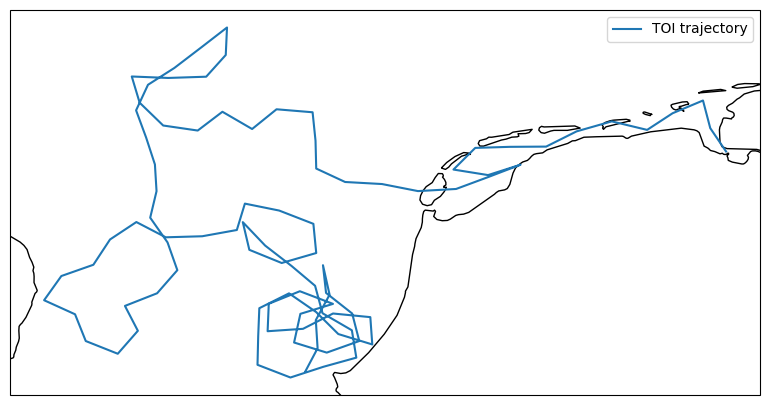

In [9]:
figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# axglobal.set_global()
axglobal.coastlines()

axglobal.plot([pos.lon_deg for pos in phenomena],[pos.lat_deg for pos in phenomena],transform=ccrs.Geodetic(), label="TOI trajectory")


axglobal.legend()


Manually add observation opportunities

In [10]:
sim_start_time = start_time

In [11]:
world_with_brokers = World(satellites = all_satellites, phenomena=phenomena)

scheduler_planet = ConstellationGroundScheduler(satellites=skysat_satellites+pelican_satellites+tanager_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Planet")
scheduler_umbra = ConstellationGroundScheduler(satellites=umbra_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Umbra")
scheduler_capella = ConstellationGroundScheduler(satellites=capella_acadia_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Capella")
scheduler_LOFT = ConstellationGroundScheduler(satellites=loft_satellites, ground_stations=ground_stations, world=world_with_brokers, name="LOFT")
scheduler_ubotica = ConstellationGroundScheduler(satellites=ubotica_satellites, ground_stations=ground_stations, world=world_with_brokers, name="UBOTICA")
scheduler_mission_control = ConstellationGroundScheduler(satellites=mission_control_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Mission Control")
scheduler_aerospace = ConstellationGroundScheduler(satellites=aerospace_corp_satellites, ground_stations=ground_stations, world=world_with_brokers, name="AC")

world_with_brokers.add_constellation(scheduler_planet)
world_with_brokers.add_constellation(scheduler_umbra)
world_with_brokers.add_constellation(scheduler_capella)
world_with_brokers.add_constellation(scheduler_LOFT)
world_with_brokers.add_constellation(scheduler_ubotica)
world_with_brokers.add_constellation(scheduler_mission_control)
world_with_brokers.add_constellation(scheduler_aerospace)




world_with_brokers = World(satellites = all_satellites, phenomena=phenomena)

# N_BACKGROUND_SAMPLES_PER_CONSTELLATION = 50


# sampled_world_cities_LOFT = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES_PER_CONSTELLATION,weights='population',axis=0, random_state=0)
# sampled_world_cities_ubotica = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES_PER_CONSTELLATION,weights='population',axis=0, random_state=1)
# sampled_world_cities_aerospace = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES_PER_CONSTELLATION,weights='population',axis=0, random_state=2)
# obs_request_LOFT = [
#     ObservationRequest(city[1].lng, city[1].lat, min_time=start_time, max_time=end_time, alt_km=0.307, request_name=city[1].city,)
#     for city in sampled_world_cities_LOFT.iterrows()
# ]
# obs_request_ubotica = [
#     ObservationRequest(city[1].lng, city[1].lat, min_time=start_time, max_time=end_time, alt_km=0.307, request_name=city[1].city,)
#     for city in sampled_world_cities_ubotica.iterrows()
# ]
# obs_request_aerospace = [
#     ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=min_time, alt_km=0.307, request_name=city[1].city,)
#     for city in sampled_world_cities_aerospace.iterrows()
# ]


# for request in obs_request_LOFT:
#     scheduler_LOFT.schedule_request(
#         request=request,
#         current_time=sim_start_time,
#         callback_request_scheduled=lambda obs: print("[LOFT] Request {} scheduled for observation {}!".format(request, obs)),
#         callback_request_ready=lambda dp: print("[LOFT] Request {} ready with DP {}!".format(request, dp)),
#         )
    
# for request in obs_request_ubotica:
#     scheduler_ubotica.schedule_request(
#         request=request,
#         current_time=sim_start_time,
#         callback_request_scheduled=lambda obs: print("[UBOTICA] Request {} scheduled for observation {}!".format(request, obs)),
#         callback_request_ready=lambda dp: print("[UBOTICA] Request {} ready with DP {}!".format(request, dp)),
#         )
    
# for request in obs_request_aerospace:
#     scheduler_aerospace.schedule_request(
#         request=request,
#         current_time=sim_start_time,
#         callback_request_scheduled=lambda obs: print("[AC] Request {} scheduled for observation {}!".format(request, obs)),
#         callback_request_ready=lambda dp: print("[AC] Request {} ready with DP {}!".format(request, dp)),
#         )
    
# scheduler_LOFT.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
# scheduler_ubotica.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
# scheduler_aerospace.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))

In [12]:
broker = Broker(constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace], world=world_with_brokers)

world_with_brokers.add_broker(broker)

In [13]:
# Let's do everything broker-side for now.
# When we receive an observation, we update the ship tracker.
# Periodically we query the ship tracker with a next set of search locations, which are passed to the broker.
# For the temporal aspect, we just query periodically.
# For the spatial aspect, let's start with "last known location"

class ShipTracker():
    def __init__(self, initial_time_dt, initial_lon_deg, initial_lat_deg):
        self.last_measurement_time = initial_time_dt
        self.lon_deg = initial_lon_deg
        self.lat_deg = initial_lat_deg

        return
    def update_location(self, new_detection: Phenomenon, new_time: dt.datetime):
        self.lon_deg = new_detection.lon_deg
        self.lat_deg = new_detection.lat_deg
        self.last_measurement_time = new_detection.end_time #Kind of cheating here

    def plan_next_search_locations(self, current_time, max_search_time):
        # Idea:
        # - Generate a bunch of points sampling the possible current location of the ship
        # - Come up with a tessellation that covers these points
        # - Return those as search areas

        return [
            ObservationRequest(
            lat_deg=self.lat_deg,
            lon_deg=self.lon_deg,
            min_time=current_time,
            max_time = max_search_time,
            alt_km=0,
            instrument="RGB",
            request_name="Ship_{}-{}".format(current_time.strftime("%Y-%m-%d %H:%M:%S"), max_search_time.strftime("%Y-%m-%d %H:%M:%S")),
            min_elevation_deg=45,
            )
        ]
    

In [14]:
# sampled_world_cities_broker = cities_of_the_world.sample(n=50,weights='population',axis=0, random_state=3)

number_of_submissions = 999

# OMNISCENT_BROKER = True
# BROKER_ALWAYS_DETECTS_SHIP = True

broker_modes = ['FIXED_GAZE', 'FIXED_GAZE_RT', 'OMNISCENT_BROKER', 'BROKER_ALWAYS_DETECTS_SHIP', 'ACTIVE_DETECTION', 'ACTIVE_DETECTION_WITH_SEARCH']

broker_mode = 'ACTIVE_DETECTION_WITH_SEARCH'

In [15]:


request_time_interval = dt.timedelta(seconds=3600)

# obs_requests_broker = [
#     ObservationRequest(Rotterdam.lon_deg, Rotterdam.lat_deg, min_time=start_time+i*request_time_interval, max_time=start_time+(i+1)*request_time_interval, alt_km=0.0, request_name=Rotterdam.name,)
#     for i in range(int(math.ceil((end_time-start_time).total_seconds()/request_time_interval.total_seconds())))
# ]

obs_requests_phenomenon = [
    ObservationRequest(p.lon_deg, p.lat_deg, min_time=p.start_time, max_time=p.end_time, alt_km=p.alt_km, request_name=Rotterdam.name, min_elevation_deg=45)
    for p in phenomena
]

search_interval_s = 1800

if broker_mode == 'FIXED_GAZE':
    # Only look at where the ship started, every 30 minutes. Schedule in advance.
    for i in range(int(math.ceil(48*3600/search_interval_s))):
        _fixed_gaze_request = ObservationRequest(
            Rotterdam.lon_deg, Rotterdam.lat_deg,
            min_time=start_time+dt.timedelta(seconds=search_interval_s)*i,
            max_time=start_time+dt.timedelta(seconds=search_interval_s)*(i+1),
            alt_km=Rotterdam.alt_km, request_name=Rotterdam.name,
            min_elevation_deg=45,
            )
        broker.schedule_request(request=_fixed_gaze_request, current_time=sim_start_time, number_of_submissions=number_of_submissions)
    
if broker_mode == 'FIXED_GAZE_RT':
    # Only look at where the ship started, every 30 minutes. Schedule in real time.
    for i in range(int(math.ceil(48*3600/search_interval_s))):
        _min_time = start_time+dt.timedelta(seconds=search_interval_s*i)
        _max_time = start_time+dt.timedelta(seconds=search_interval_s*(i+1))
        _event = Event(
            time=_min_time,
            name="RFixed_{}".format(_min_time),
            action_callable = lambda _mit=_min_time, _mat=_max_time, ns=number_of_submissions: 
            broker.schedule_request(
                request = ObservationRequest(
                    Rotterdam.lon_deg, Rotterdam.lat_deg,
                    min_time=_mit,
                    max_time=_mat,
                    alt_km=Rotterdam.alt_km, request_name=Rotterdam.name,
                    min_elevation_deg=45,
                ),
                current_time=_mit,
                number_of_submissions=ns
                )
        )
        # This schedules the next batch of observations right at the beginning of the window. We expect that there may be loads of conflicts as we don't have enough time to get the request in...
        world_with_brokers.add_event(_event)


elif broker_mode == 'OMNISCENT_BROKER':
    # Schedule all searches at the right place, ahead of time
    for _req in obs_requests_phenomenon:
        broker.schedule_request(_req, current_time=sim_start_time, number_of_submissions=number_of_submissions)

elif broker_mode == 'BROKER_ALWAYS_DETECTS_SHIP':
    # Schedule at the right place, just ahead of time
    for _req in obs_requests_phenomenon:
        _event = Event(
            time=_req.min_time,
            name=_req.name,
            action_callable = lambda __req=_req, ct=_req.min_time, ns=number_of_submissions: broker.schedule_request(__req, current_time=ct, number_of_submissions=ns)
        )
        # This schedules the next batch of observations right at the beginning of the window. We expect that there may be loads of conflicts as we don't have enough time to get the request in...
        world_with_brokers.add_event(_event)

elif broker_mode == 'ACTIVE_DETECTION' or broker_mode == 'ACTIVE_DETECTION_WITH_SEARCH':
    followup_horizon_s = 7200
    time_to_schedule_followup = 10

    # Event:
    # - schedule an observation
    # - with a callback that does the following:
    #   - update the ShipTracker
    #   - ask for the next location
    #   - schedule a new observation
    # Schedule a first look where we think the ship is.
    # When the information comes back, feed it to ShipTracker.
    # Then immediately invoke ShipTracker to get a new search location.
    # It will always look at the last place where the ship was.

    ship_tracker = ShipTracker(initial_lon_deg=Rotterdam.lon_deg, initial_lat_deg=Rotterdam.lat_deg, initial_time_dt=start_time)
    
    def get_follow_up_events(_ship_tracker, _current_time, followup_horizon_s, time_to_schedule_followup, number_of_submissions):
        follow_up_observations = _ship_tracker.plan_next_search_locations(
            current_time = _current_time,
            max_search_time=_current_time+dt.timedelta(seconds=followup_horizon_s)
            )
        follow_up_events = []
        for follow_up_observation in follow_up_observations:
            follow_up_events.append(
                Event(
                    time=_current_time+dt.timedelta(seconds=time_to_schedule_followup),
                    action_callable = lambda __req=follow_up_observation, ct=_current_time, ns=number_of_submissions:
                    broker.schedule_request(
                        __req,
                        current_time=ct,
                        number_of_submissions=ns,
                        follow_up_action_success=observation_follow_up # This is the key recursive aspect.
                    ),
                    name="Follow-up search {}".format(_current_time)
                )
            )
        return follow_up_events

    def schedule_follow_up_events(_world: World, _ship_tracker: ShipTracker, followup_horizon_s: int, time_to_schedule_followup: int, number_of_submissions: int ):
        follow_up_events = get_follow_up_events(_ship_tracker, _world.time, followup_horizon_s, time_to_schedule_followup, number_of_submissions) # You can write C in any language, uh.
        for _follow_up_event in follow_up_events:
            print("&&& [{} ]Adding event {} with time {} to world".format(_world.time, _follow_up_event.name, _follow_up_event.time))
            _world.add_event(_follow_up_event)

    def observation_follow_up(data_product):
        # This fires when a follow-up is detected 
        current_time = world_with_brokers.time #I Think this will be evaluated lazily?
        # Update location
        if data_product is not None:
            if len(data_product)>0:
                if len(data_product)>1:
                    raise Exception("Why do we have multiple detections?")
                ship_tracker.update_location(new_detection=data_product[0], new_time=current_time)
        
        # Get new observations
        schedule_follow_up_events(
            _world=world_with_brokers,
            _ship_tracker=ship_tracker,
            followup_horizon_s=followup_horizon_s,
            time_to_schedule_followup=time_to_schedule_followup,
            number_of_submissions=number_of_submissions
            )
    
    initial_request = ObservationRequest(
        lon_deg=Rotterdam.lon_deg,
        lat_deg=Rotterdam.lat_deg,
        min_time=start_time,
        max_time=start_time+dt.timedelta(seconds=7200),
        alt_km=0,
        instrument="RGB",
        request_name="Rotterdam initial",
        min_elevation_deg=45
    )

    initial_event = Event(
        time=start_time,
        action_callable = lambda __req=initial_request, ct=start_time, ns=number_of_submissions:
        broker.schedule_request(
            __req,
            current_time=ct,
            number_of_submissions=ns,
            follow_up_action_success=observation_follow_up # This is the key recursive aspect.
            ),
            name="Initial search"
    )

    world_with_brokers.add_event(initial_event)

    if broker_mode == 'ACTIVE_DETECTION_WITH_SEARCH':
         # Same as ACTIVE_DETECTION, plus a search every x minutes.
         # Have an event every 30 mins
         # The event is
         # Get list of observations from the ship searcher
         # Schedule those observations

        search_events = [
            Event(
                time=start_time+dt.timedelta(seconds=search_interval_s)*i,
                action_callable = lambda: schedule_follow_up_events(
                    _world=world_with_brokers,
                    _ship_tracker=ship_tracker,
                    followup_horizon_s=followup_horizon_s,
                    time_to_schedule_followup=time_to_schedule_followup,
                    number_of_submissions=number_of_submissions
                ),
                name="Periodic search trigger"
            )
            for i in range(int(math.ceil(48*3600/search_interval_s)))
        ]
        for _search_event in search_events:
            world_with_brokers.add_event(_search_event)

    # broker.schedule_request(_req, current_time=sim_start_time, number_of_submissions=number_of_submissions)

In [16]:
world_with_brokers.events

[Event Initial search at 2026-02-14 00:00:00,
 Event Periodic search trigger at 2026-02-14 00:00:00,
 Event Periodic search trigger at 2026-02-14 00:30:00,
 Event Periodic search trigger at 2026-02-14 01:00:00,
 Event Periodic search trigger at 2026-02-14 01:30:00,
 Event Periodic search trigger at 2026-02-14 02:00:00,
 Event Periodic search trigger at 2026-02-14 02:30:00,
 Event Periodic search trigger at 2026-02-14 03:00:00,
 Event Periodic search trigger at 2026-02-14 03:30:00,
 Event Periodic search trigger at 2026-02-14 04:00:00,
 Event Periodic search trigger at 2026-02-14 04:30:00,
 Event Periodic search trigger at 2026-02-14 05:00:00,
 Event Periodic search trigger at 2026-02-14 05:30:00,
 Event Periodic search trigger at 2026-02-14 06:00:00,
 Event Periodic search trigger at 2026-02-14 06:30:00,
 Event Periodic search trigger at 2026-02-14 07:00:00,
 Event Periodic search trigger at 2026-02-14 07:30:00,
 Event Periodic search trigger at 2026-02-14 08:00:00,
 Event Periodic sea

In [17]:
retcode = 1
while (retcode !=0):
    # print("Tick!")
    retcode = world_with_brokers.tick(print_forbidden_prefixes=["Downlink", "End of downlink", "Unlock uplink", "Unlock satellite after obs"])
    # print(world_with_brokers.events)

Executing Event Initial search at 2026-02-14 00:00:00
[Broker] scheduling request Request Rotterdam initial | Lon 3.8°, lat 52°, alt 0 km from 2026-02-14 00:00:00 to 2026-02-14 02:00:00 with RGB, min elevation 45 deg
Best request: Pass start: 2026-02-14 01:18:24.098776, highest: 2026-02-14 01:19:13.843065, fall: 2026-02-14 01:20:05.719953 with SKYSAT-C8
[Planet] Scheduling request Request Rotterdam initial | Lon 3.8°, lat 52°, alt 0 km from 2026-02-14 01:17:24.098776 to 2026-02-14 01:21:05.719953 with RGB, min elevation 45 deg
 [Planet] Best request: Pass start: 2026-02-14 01:18:24.098776, highest: 2026-02-14 01:19:14.909365, fall: 2026-02-14 01:20:05.719953 with SKYSAT-C8
 [Broker] confirmed scheduling of request Request Rotterdam initial | Lon 3.8°, lat 52°, alt 0 km from 2026-02-14 00:00:00 to 2026-02-14 02:00:00 with RGB, min elevation 45 deg from pass Pass start: 2026-02-14 01:18:24.098776, highest: 2026-02-14 01:19:13.843065, fall: 2026-02-14 01:20:05.719953, constellation Planet

In [18]:
def request_statistics(requests_pd):
    total_requests_no = len(requests_pd)
    all_statuses = set(requests_pd.status.values)    
    for s in all_statuses:
        # matching_statuses = sum([1 if (r['status']==s) else 0 for r in requests.values()])
        matching_statuses = len(requests_pd[requests_pd.status==s])
        print("{}/{} ({}%) of requests are in status {}".format(matching_statuses,total_requests_no, matching_statuses/total_requests_no*100, s))
    # X/Y requests have >1 successful observation
    
    requests_with_detections = requests_pd.apply(lambda x: x['data_product'] is not None and len(x['data_product'])>0, axis=1)

    if len(requests_pd[requests_pd.status=="OK! Data received"])>0:
        print("{}/{} ({}%) successful requests have a phenomenon detection".format(sum(requests_with_detections), len(requests_pd[requests_pd.status=="OK! Data received"]),sum(requests_with_detections)/len(requests_pd[requests_pd.status=="OK! Data received"])*100))
    
    unique_requests = set(requests_pd.request)
    unique_requests_no = len(unique_requests)
    fulfilled_unique_requests_no = 0
    fulfilled_unique_requests_events_found_no = 0
    for ur in unique_requests:
        matching_observation_statuses = requests_pd[(requests_pd['request']==ur) & (requests_pd['status']=="OK! Data received")]
        if len(matching_observation_statuses):
            fulfilled_unique_requests_no += 1
        for _dp in matching_observation_statuses['data_product']:
            if _dp is not None and len(_dp):
                fulfilled_unique_requests_events_found_no += 1
                break
    print(" {}/{} ({}%) unique requests have at least one successful observation".format(fulfilled_unique_requests_no, unique_requests_no, fulfilled_unique_requests_no/unique_requests_no*100))
    # for _ix, _dp in requests_pd:
    # print(" of all requests have a phenomenon detection")
    # print(" of all _successful_ requests have a phenomenon detection")

    # print(" of all unique requests have a phenomenon detection")
    if fulfilled_unique_requests_no>0:
        print("{}/{} ({}%) of all successful unique requests have a phenomenon detection".format(fulfilled_unique_requests_events_found_no, fulfilled_unique_requests_no, fulfilled_unique_requests_events_found_no/fulfilled_unique_requests_no*100))

In [19]:
request_statistics(broker._requests)

76/202 (37.62376237623762%) of requests are in status OK! Data received
24/202 (11.881188118811881%) of requests are in status No observation opportunities
1/202 (0.49504950495049505%) of requests are in status All observation opportunities are conflicting
101/202 (50.0%) of requests are in status No unconflicted observation opportunities
13/76 (17.105263157894736%) successful requests have a phenomenon detection
 49/173 (28.32369942196532%) unique requests have at least one successful observation
10/49 (20.408163265306122%) of all successful unique requests have a phenomenon detection


TODO:
- [X] Updated position
- [ ] Estimate new position if we change velocity
- [X] Histogram 

In [20]:
def retell_history(world: World):
    for _chronicle in world.history:
        print("Time: {}. Event: {}".format(_chronicle['time'], _chronicle['event']))
        if type(_chronicle['event'])==ObservationEvent:
            print("Observation: sat {} and opportunity {}".format(_chronicle['event'].satellite, _chronicle['event'].opportunity))
        if type(_chronicle['event'])==CommunicationEvent:
            print("Communication: station {} to sat {} during pass {}".format(_chronicle['event'].station, _chronicle['event'].satellite, _chronicle['event'].comm_pass))

In [21]:
retell_history(world_with_brokers)

Time: 2026-02-14 00:00:00. Event: Event Initial search at 2026-02-14 00:00:00
Time: 2026-02-14 00:00:00. Event: Event Periodic search trigger at 2026-02-14 00:00:00
Time: 2026-02-14 00:00:10. Event: Event Follow-up search 2026-02-14 00:00:00 at 2026-02-14 00:00:10
Time: 2026-02-14 00:08:23.410859. Event: Event Uplink, station KSAT Vardo to sat LOFT YAM-6 at 2026-02-14 00:08:23.410859
Communication: station Location KSAT Vardo | Lon 31.12509°, lat 70.36779°, alt 0 km to sat LOFT YAM-6 during pass Pass start: 2026-02-14 00:05:53.694363, highest: 2026-02-14 00:08:23.410859, fall: 2026-02-14 00:10:57.779360
Time: 2026-02-14 00:08:43.677892. Event: Event Uplink, station KSAT Nemea to sat SKYSAT-C6 at 2026-02-14 00:08:43.677892
Communication: station Location KSAT Nemea | Lon 22.62216°, lat 37.84604°, alt 0 km to sat SKYSAT-C6 during pass Pass start: 2026-02-14 00:06:14.741796, highest: 2026-02-14 00:08:43.677892, fall: 2026-02-14 00:11:08.495844
Time: 2026-02-14 00:10:57.779360. Event: Even

In [22]:
scheduler_planet._requests

,request,satellite,observation,uplink,downlink,status,data_product,scheduled_callback,unscheduled_callback,ready_callback
0,"Request Rotterdam initial | Lon 3.8°, lat 52°,...",SKYSAT-C8,Observation at 2026-02-14 01:19:14.909365 wit...,"Pass start: 2026-02-14 01:13:17.222455, highes...","Pass start: 2026-02-14 01:23:38.233536, highes...",OK! Data received,"[Rotterdam-ish 2026-02-14, 01-01: Lon 3.888932...",<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...
1,"Request Rotterdam initial | Lon 3.8°, lat 52°,...",SKYSAT-C6,Observation at 2026-02-14 01:46:00.959602 wit...,"Pass start: 2026-02-14 00:06:14.741796, highes...","Pass start: 2026-02-14 01:50:52.786349, highes...",OK! Data received,[],<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...
2,Request Ship_2026-02-14 06:00:00-2026-02-14 08...,SKYSAT-C2,Observation at 2026-02-14 07:53:31.959416 wit...,"Pass start: 2026-02-14 06:11:23.944077, highes...","Pass start: 2026-02-14 09:03:11.233195, highes...",OK! Data received,"[Rotterdam-ish 2026-02-14, 07-08: Lon 3.790023...",<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...
3,Request Ship_2026-02-14 07:00:00-2026-02-14 09...,None,None,None,None,No observation opportunities,None,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...
4,Request Ship_2026-02-14 07:00:00-2026-02-14 09...,SKYSAT-C13,Observation at 2026-02-14 08:39:46.101507 wit...,"Pass start: 2026-02-14 07:00:48.163494, highes...","Pass start: 2026-02-14 09:50:00.456928, highes...",OK! Data received,"[Rotterdam-ish 2026-02-14, 08-09: Lon 4.304425...",<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...
5,Request Ship_2026-02-14 08:30:00-2026-02-14 10...,PELICAN-6,Observation at 2026-02-14 10:27:31.040089 wit...,"Pass start: 2026-02-14 08:43:54.858471, highes...","Pass start: 2026-02-14 10:58:33.837132, highes...",OK! Data received,"[Rotterdam-ish 2026-02-14, 10-10: Lon 3.893020...",<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...
6,Request Ship_2026-02-14 09:00:00-2026-02-14 11...,PELICAN-300A,Observation at 2026-02-14 10:40:20.422180 wit...,"Pass start: 2026-02-14 09:08:05.111162, highes...","Pass start: 2026-02-14 11:11:44.704271, highes...",OK! Data received,"[Rotterdam-ish 2026-02-14, 10-11: Lon 3.689640...",<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...
7,Request Ship_2026-02-14 09:00:00-2026-02-14 11...,PELICAN-5,Observation at 2026-02-14 10:40:16.423960 wit...,"Pass start: 2026-02-14 09:06:14.632677, highes...","Pass start: 2026-02-14 11:12:02.390067, highes...",OK! Data received,"[Rotterdam-ish 2026-02-14, 10-11: Lon 3.689640...",<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...
8,Request Ship_2026-02-14 09:08:35-2026-02-14 11...,PELICAN-300B,Observation at 2026-02-14 11:02:34.458178 wit...,"Pass start: 2026-02-14 09:20:39.397472, highes...","Pass start: 2026-02-14 12:12:22.532251, highes...",OK! Data received,[],<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...
9,Request Ship_2026-02-14 09:30:00-2026-02-14 11...,None,None,None,None,No observation opportunities,None,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedule_request.<locals>.cal...,<function Broker.schedu